In [6]:
import numpy as np
import pandas as pd
from pathlib import Path
import flexiznam as flz
import sys
from cottage_analysis.preprocessing import synchronisation
from cottage_analysis.analysis.gratings import generate_trials_df
from cottage_analysis.analysis.gratings import analyze_grating_responses

In [7]:
project_name = "toksozi_in-vivo-BRISC"
mouse_name   = "BRAC10754.8c"
session_name = "S20251028"
protocol     = "SFTF"

print(f"Configuration Loaded: {mouse_name} / {session_name}")

Configuration Loaded: BRAC10754.8c / S20251028


In [8]:
def find_recordings(p_name, m_name, s_name, proto, base_dir="/Volumes/lab-znamenskiyp/home/shared/projects/"):
    base_path = Path(base_dir)
    session_path = base_path / p_name / m_name / s_name
    
    if not session_path.exists():
        print(f"[ERROR] Path not found: {session_path}")
        return None, None, None

    print(f"\nLooking for recordings in: {session_path}")
    recordings = sorted([p for p in session_path.iterdir() if p.is_dir() and p.name.startswith("R")])
    
    if not recordings:
        print("[WARNING] No recordings found starting with 'R' in this session folder.")
        return None, None, None

    print(f"Found {len(recordings)} recording(s).")
    flexiznam_session_id = f"{m_name}_{s_name}"
    
    return p_name, flexiznam_session_id, proto


In [9]:
def run_analysis(project_name, session_id, protocol):
    if not project_name or not session_id:
        print("Invalid project or session ID. Aborting analysis.")
        return

    print(f"\n>>> Starting {protocol} analysis for {session_id}...")
    
    try:
        trials_df, dff_mean_all = analyze_grating_responses(
            project=project_name,
            session=session_id,
            protocol_base=protocol
        )
        
        print("\n>>> Analysis Complete!")
        print(f"Result: Trials DataFrame with shape {trials_df.shape}")

        return trials_df, dff_mean_all

    except Exception as e:
        print(f"\n[ERROR] Analysis failed: {e}")
        import traceback
        traceback.print_exc()
        return None, None

In [10]:
if __name__ == "__main__":
    # Find the recordings
    proj, sess_id, proto = find_recordings(project_name, mouse_name, session_name, protocol)
    
    # If valid recordings were found, run the analysis
    if proj and sess_id:
        trials_df, dff_mean = run_analysis(proj, sess_id, proto)
    
    print("\nFirst 5 rows of your data:")
    display(trials_df.head())

    


Looking for recordings in: /Volumes/lab-znamenskiyp/home/shared/projects/toksozi_in-vivo-BRISC/BRAC10754.8c/S20251028
Found 1 recording(s).

>>> Starting SFTF analysis for BRAC10754.8c_S20251028...
Loading existing monitor frames...
Removing frames in wrong order of frame indices.
Removed 12 frames including:
0 negative diffs.
12 duplicates.
Removed 0 frames including:
0 negative diffs.
0 duplicates.
2 frames are not 0.0334 s
ImagingFrames in video: 206024
ImagingFrame triggers: 206027
Triggers - Frames: 3
FRAME NUMBER NOT CORRECT likely due to incomplete imaging volume at the end of the stack or bonsai crash.

>>> Analysis Complete!
Result: Trials DataFrame with shape (1709, 23)

First 5 rows of your data:


,imaging_harptime,imaging_frame,imaging_volume,imaging_harptime_end,monitor_frame,monitor_harptime,mouse_z,eye_z,stimulus_harptime,Frameindex,...,TemporalFrequency,Angle,Phase,mouse_z_harptime,mouse_z_harp,dffs,stim_start,stim_end,dff_stim,irecording
0,1.034472e+07,1064,152,1.034472e+07,5294,1.034472e+07,356.32,356.32,1.034472e+07,5263.0,...,1.0,315.0,0.0,1.034472e+07,5.471249,"[[-0.23258994673906275, -0.18253380045638334, ...",154,171.0,"[[0.45879047306594456, 0.7543742300926913, 0.2...",BRAC10754.8c_S20251028_R094333_SFTF
1,1.034472e+07,1183,169,1.034472e+07,5847,1.034472e+07,366.86,366.86,1.034472e+07,5824.0,...,1.0,90.0,0.0,1.034472e+07,5.627869,"[[0.19925032081321187, -0.45551256528969947, -...",171,188.0,"[[0.7203394544269534, 0.23473948837401354, -0....",BRAC10754.8c_S20251028_R094333_SFTF
2,1.034472e+07,1302,186,1.034472e+07,6407,1.034472e+07,404.17,404.17,1.034472e+07,6384.0,...,2.0,90.0,0.0,1.034472e+07,6.210628,"[[-0.3757993264900213, 0.6700018120798173, -0....",188,205.0,"[[-1.1126181459834852, 0.015955246171212644, 0...",BRAC10754.8c_S20251028_R094333_SFTF
3,1.034473e+07,1421,203,1.034473e+07,6963,1.034473e+07,447.36,447.36,1.034473e+07,6944.0,...,8.0,90.0,0.0,1.034473e+07,6.871620,"[[1.4338027810094958, 0.11640877368194778, 0.2...",205,222.0,"[[0.5486756262718488, -0.13005574228685207, 1....",BRAC10754.8c_S20251028_R094333_SFTF
4,1.034473e+07,1540,220,1.034473e+07,7519,1.034473e+07,471.60,471.60,1.034473e+07,7504.0,...,1.0,90.0,0.0,1.034473e+07,7.234560,"[[1.0727640744027727, 0.17271503492376822, 0.4...",222,239.0,"[[-0.5555062884556562, 0.016338675633810206, 0...",BRAC10754.8c_S20251028_R094333_SFTF


In [11]:
import pandas as pd
import numpy as np
from cottage_analysis.analysis.fit_gaussian_blob import fit_sftf_tuning
import os

base_save_dir = Path("analysis_dataframes")
save_path = base_save_dir / mouse_name / session_name / protocol
save_path.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {save_path.resolve()}")
trials_file = save_path / "trials_df.pkl"
neurons_file = save_path / "neurons_df.pkl"

if neurons_file.exists() and trials_file.exists():
    print("Found saved data! Loading from disk...")
    neurons_df = pd.read_pickle(neurons_file)
    trials_df = pd.read_pickle(trials_file)  # Load this too!
    print(f"Loaded {len(neurons_df)} neurons from: {save_path}")

elif 'trials_df' not in locals():
    print("ERROR: 'trials_df' is missing.")
    print("Please make sure you ran the 4th/5th kernel (analysis) successfully.")


else:
    print(f"No data found in {save_path}")
    print("Running full analysis...")

    # Stack turns the list of arrays into a big matrix (Trials x Neurons)
    response_matrix = np.stack(trials_df['dff_stim'].apply(lambda x: np.mean(x, axis=0)).values)

    # Create a DataFrame with integer column names (0, 1, 2...)
    # These integers effectively become the "ROI IDs"
    responses_df = pd.DataFrame(
        response_matrix, 
        columns=np.arange(response_matrix.shape[1]), 
        index=trials_df.index
    )

    # Combine with the stimulus information
    # We keep the original stimulus columns and add the new neuron columns
    trials_df_formatted = pd.concat(
        [trials_df[['SpatialFrequency', 'TemporalFrequency', 'Angle']], responses_df], 
        axis=1
    )

    print(f"Data formatted! New shape: {trials_df_formatted.shape}")
    print(f" (Should be approx {len(trials_df)} rows x {response_matrix.shape[1] + 3} columns)")

    # Run the fit on the formatted data
    print("\nFitting Gaussian blobs... (This may take 1-5 minutes)")
    neurons_df = fit_sftf_tuning(trials_df_formatted)

    print("\nFitting complete!")
    print(f"Neurons DataFrame shape: {neurons_df.shape}")
    display(neurons_df.head())

    print(f"Saving dataframes to: {save_path}")
    trials_df.to_pickle(trials_file)
    neurons_df.to_pickle(neurons_file)
    print("Analysis complete and saved.")

Working directory: /Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/analysis_dataframes/BRAC10754.8c/S20251028/SFTF
Found saved data! Loading from disk...
Loaded 1776 neurons from: analysis_dataframes/BRAC10754.8c/S20251028/SFTF


Data ready for plotting.
Plotting ROI 1133 (R2: 0.14)


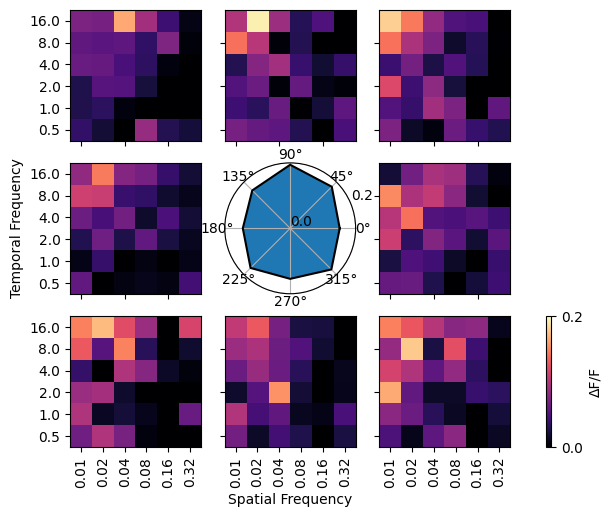

Plotting ROI 1134 (R2: 0.01)


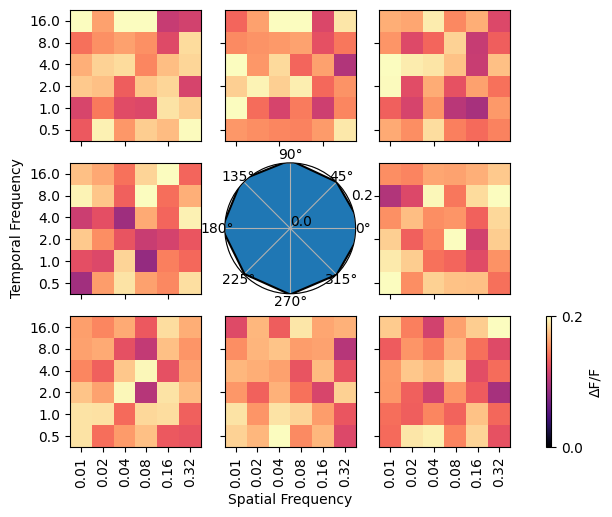

Plotting ROI 1135 (R2: 0.01)


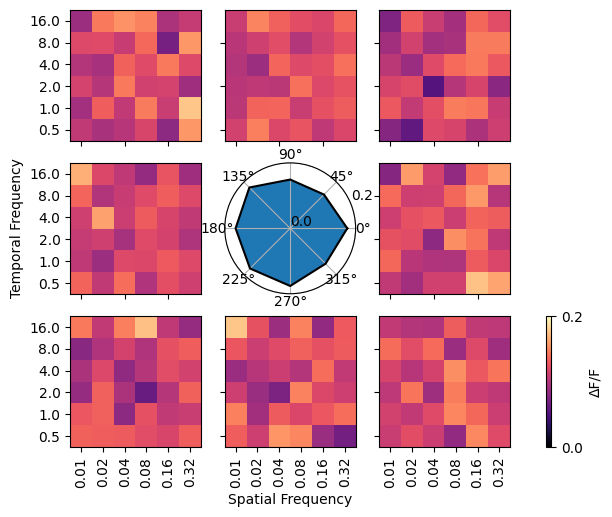

Plotting ROI 1136 (R2: 0.01)


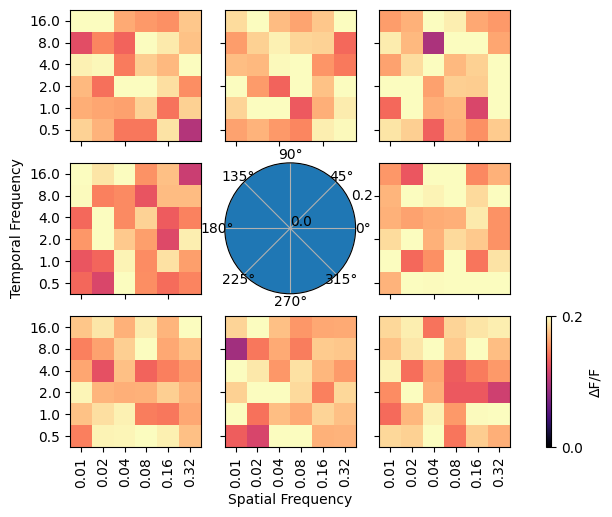

Plotting ROI 1137 (R2: 0.01)


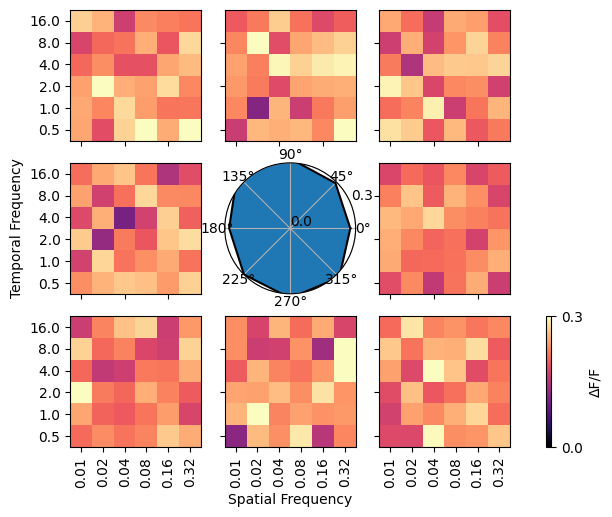

Plotting ROI 1138 (R2: 0.01)


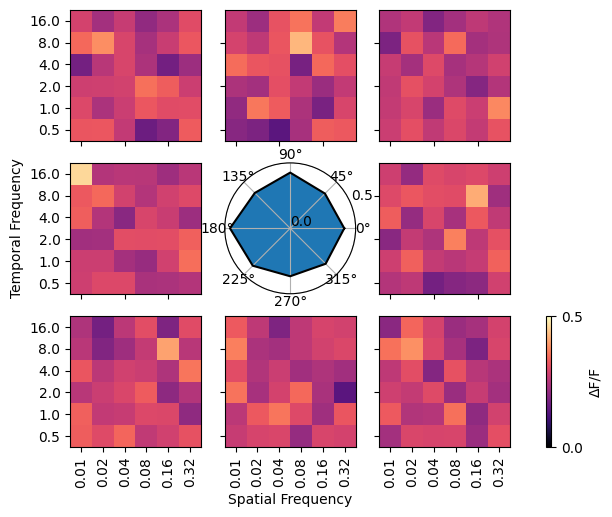

Plotting ROI 1139 (R2: 0.12)


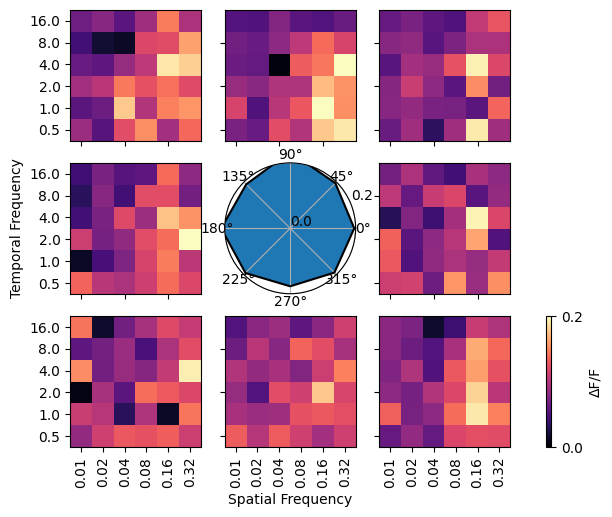

Plotting ROI 1140 (R2: 0.02)


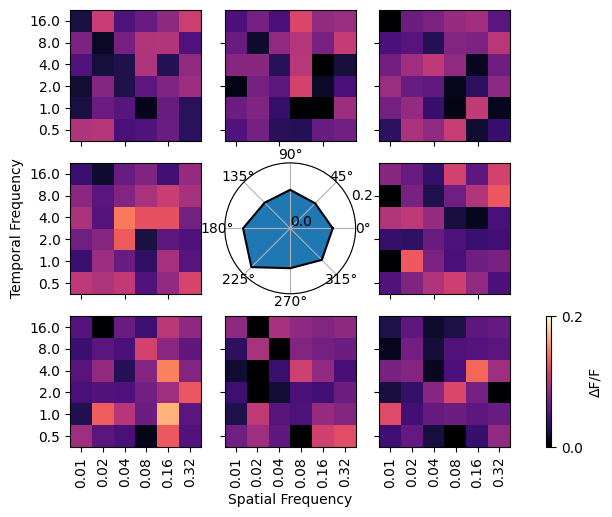

Plotting ROI 1141 (R2: 0.00)


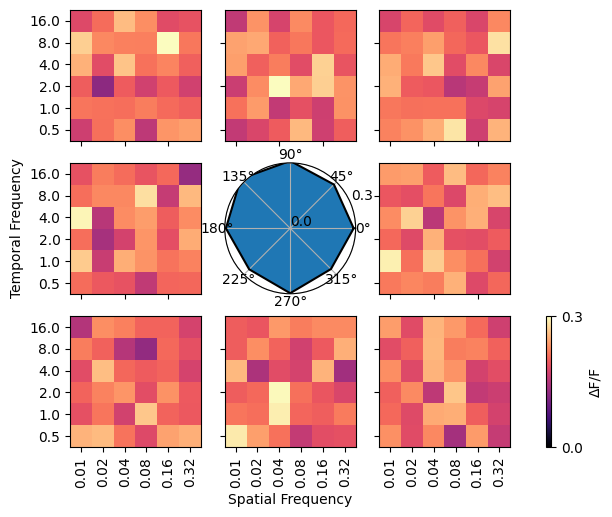

Plotting ROI 1142 (R2: 0.01)


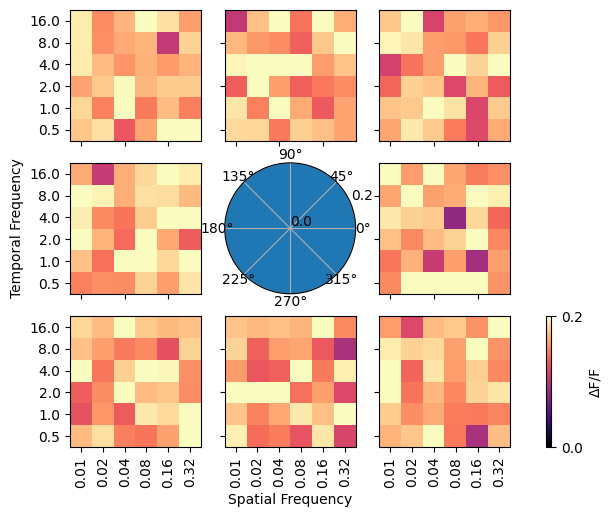

Plotting ROI 1143 (R2: 0.08)


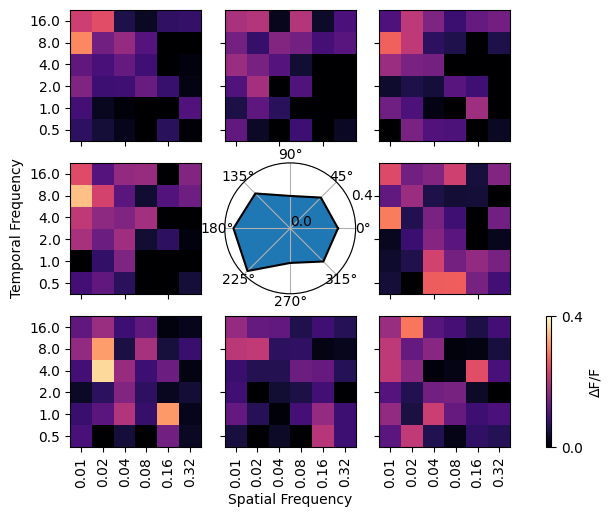

Plotting ROI 1144 (R2: 0.01)


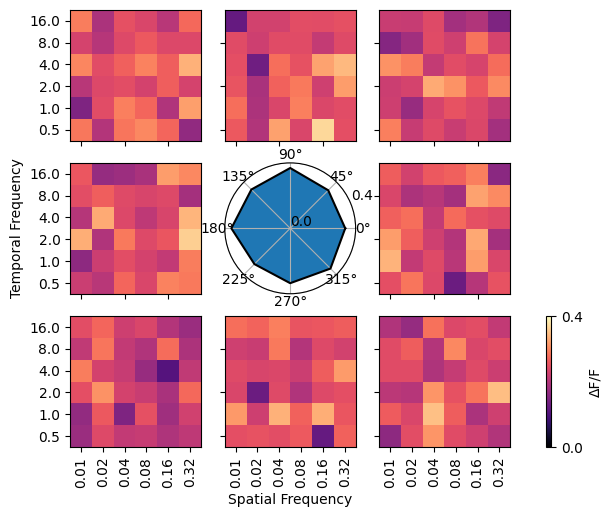

Plotting ROI 1145 (R2: 0.04)


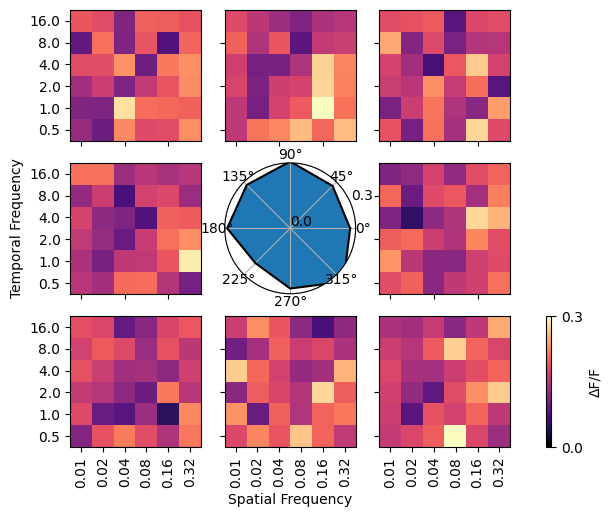

Plotting ROI 1146 (R2: 0.06)


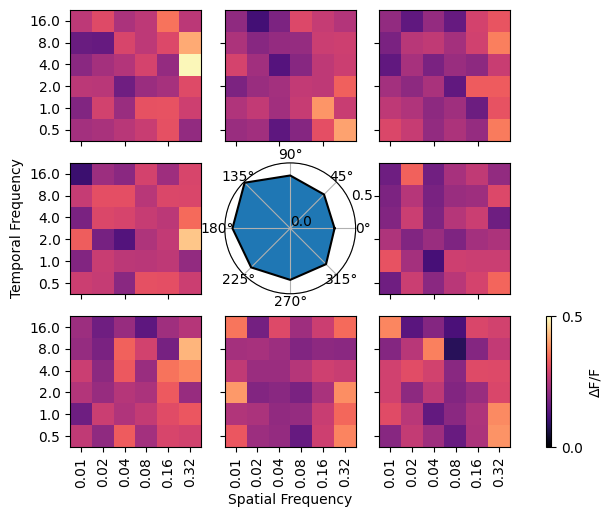

Plotting ROI 1147 (R2: 0.31)


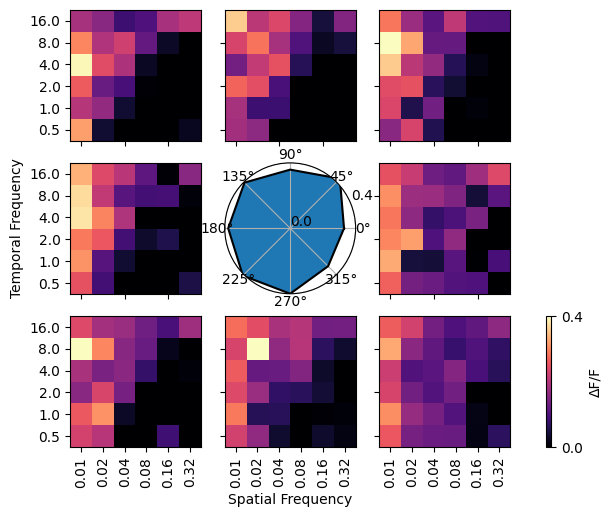

Plotting ROI 1148 (R2: 0.01)


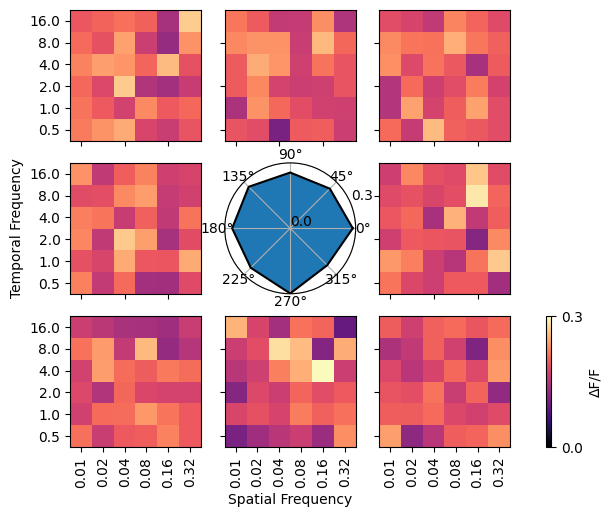

Plotting ROI 1149 (R2: 0.12)


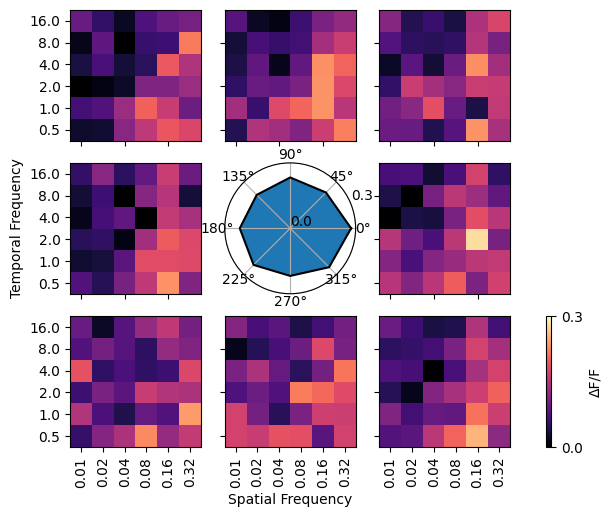

Plotting ROI 1150 (R2: 0.03)


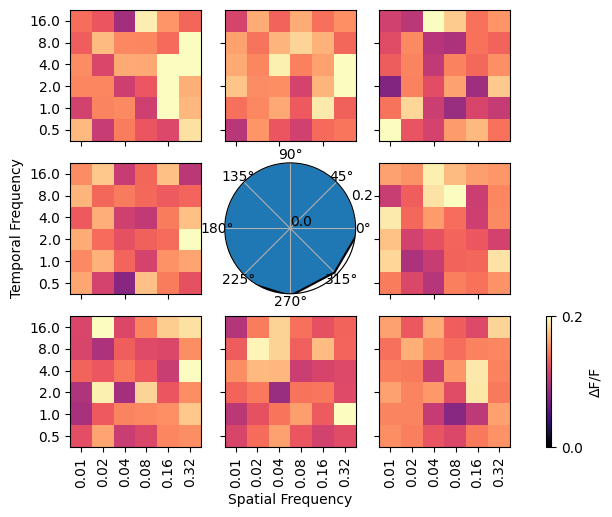

Plotting ROI 1151 (R2: 0.02)


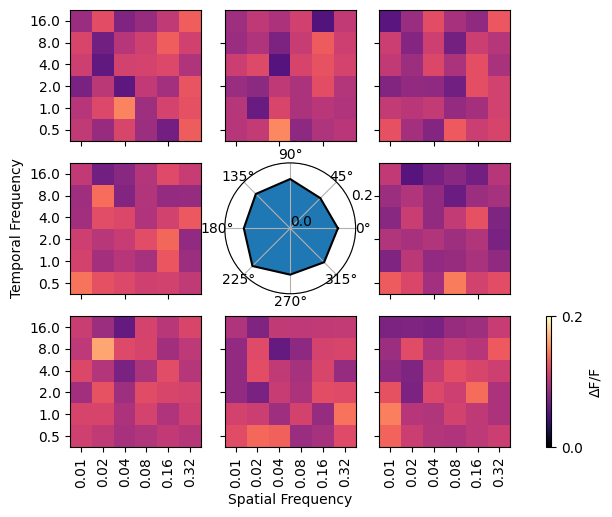

Plotting ROI 1152 (R2: 0.01)


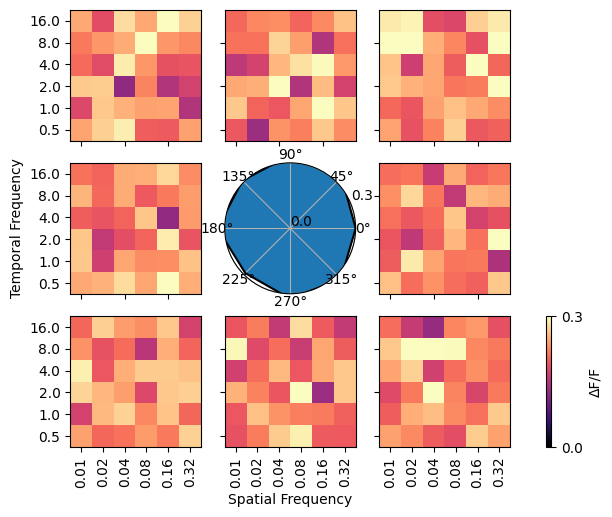

Plotting ROI 1153 (R2: 0.02)


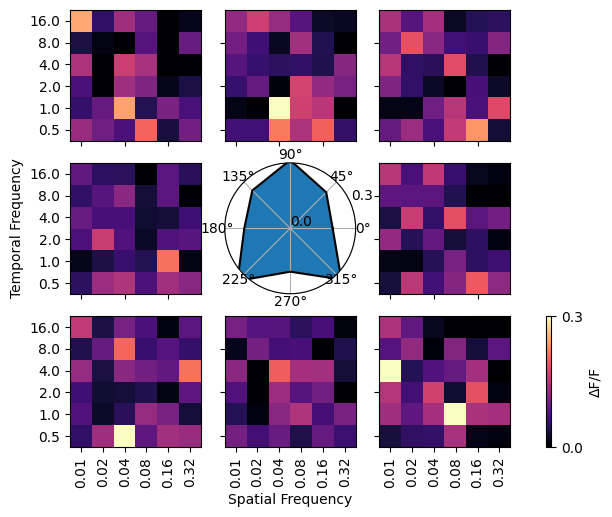

Plotting ROI 1154 (R2: 0.01)


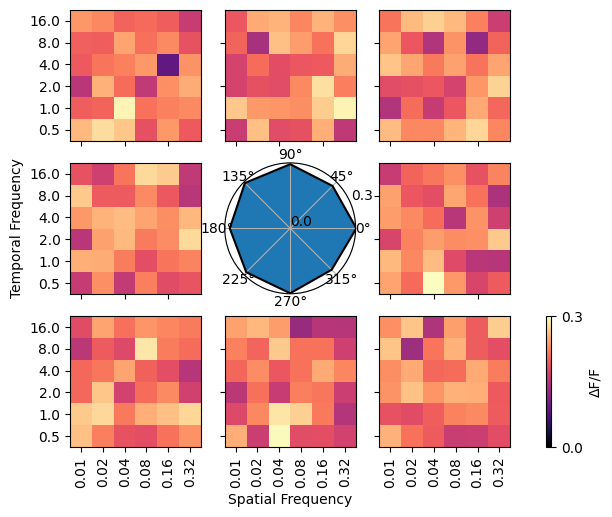

Plotting ROI 1155 (R2: 0.05)


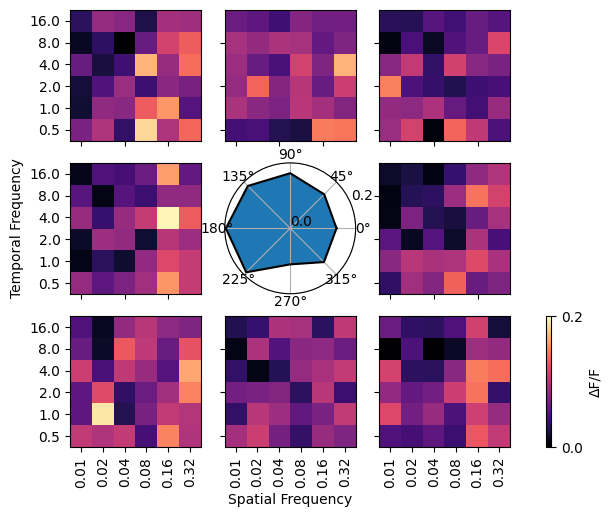

Plotting ROI 1156 (R2: 0.38)


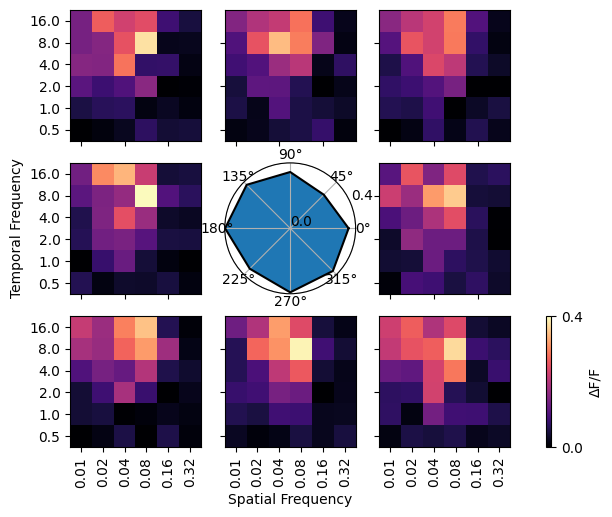

Plotting ROI 1157 (R2: 0.01)


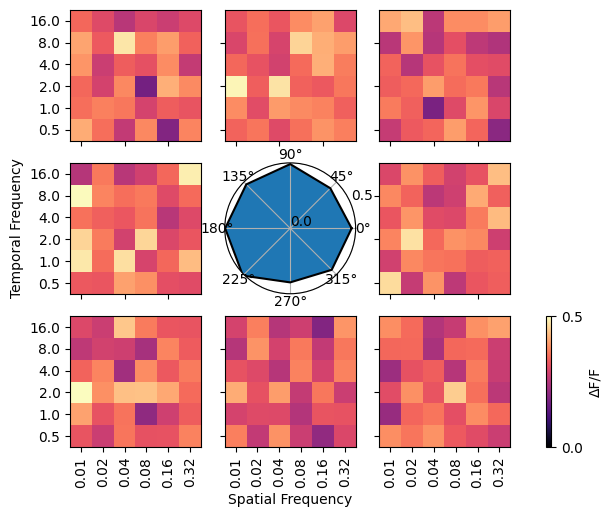

Plotting ROI 1158 (R2: 0.23)


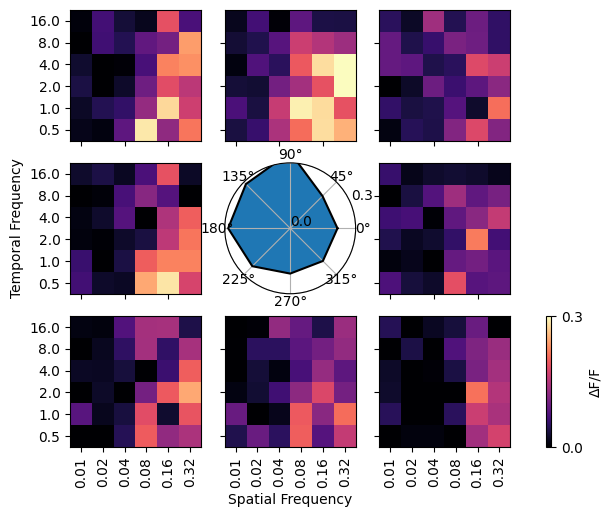

Plotting ROI 1159 (R2: 0.01)


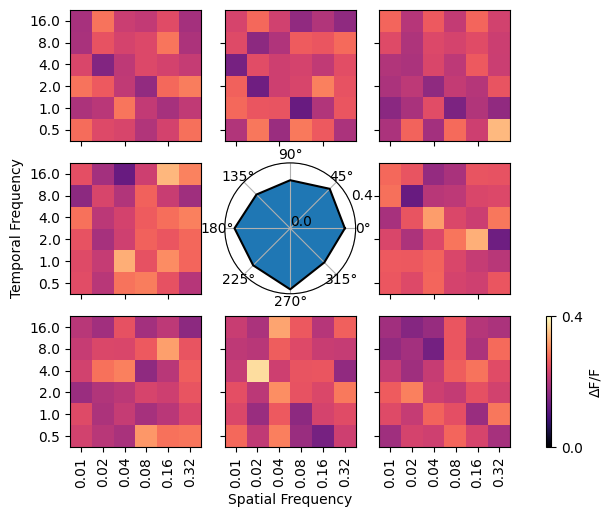

In [20]:
from cottage_analysis.plotting import grating_plots
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

base_save_dir = Path("analysis_dataframes")
save_path = base_save_dir / mouse_name / session_name / protocol
trials_file = save_path / "trials_df.pkl"
neurons_file = save_path / "neurons_df.pkl"

if 'trials_df_formatted' not in locals() or 'neurons_df' not in locals():
    print("Data missing from memory. Reloading from disk...")
    
    if not (trials_file.exists() and neurons_file.exists()):
        raise FileNotFoundError(f"Saved files not found at {save_path}. Run analysis first.")

    # Load raw files
    neurons_df = pd.read_pickle(neurons_file)
    trials_df_raw = pd.read_pickle(trials_file)

    print("Re-formatting trials dataframe (unpacking neurons)...")
    response_matrix = np.stack(trials_df_raw['dff_stim'].apply(lambda x: np.mean(x, axis=0)).values)
    
    responses_df = pd.DataFrame(
        response_matrix, 
        columns=np.arange(response_matrix.shape[1]), 
        index=trials_df_raw.index
    )
    
    trials_df_formatted = pd.concat(
        [trials_df_raw[['SpatialFrequency', 'TemporalFrequency', 'Angle']], responses_df], 
        axis=1
    )
print("Data ready for plotting.")

for found_rois in range(1133, 1160):
    # Safety check: ensure ROI exists in the data
    if found_rois not in neurons_df.index:
        print(f"Skipping ROI {found_rois} (Not found in data)")
        continue

    rsq = neurons_df.loc[found_rois, 'rsq']
    print(f"Plotting ROI {found_rois} (R2: {rsq:.2f})")

    plt.figure(figsize=(5, 5))

    # Now this is guaranteed to work
    grating_plots.plot_sftf_tuning(
        trials_df=trials_df_formatted, 
        roi=found_rois,
        plot_grid=True 
    )

    plt.show()



Generating full report for ROI 1159...


/Users/toksozi/code/cottage_analysis/cottage_analysis/plotting/grating_plots.py:311: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.005)


<Figure size 1500x1000 with 0 Axes>

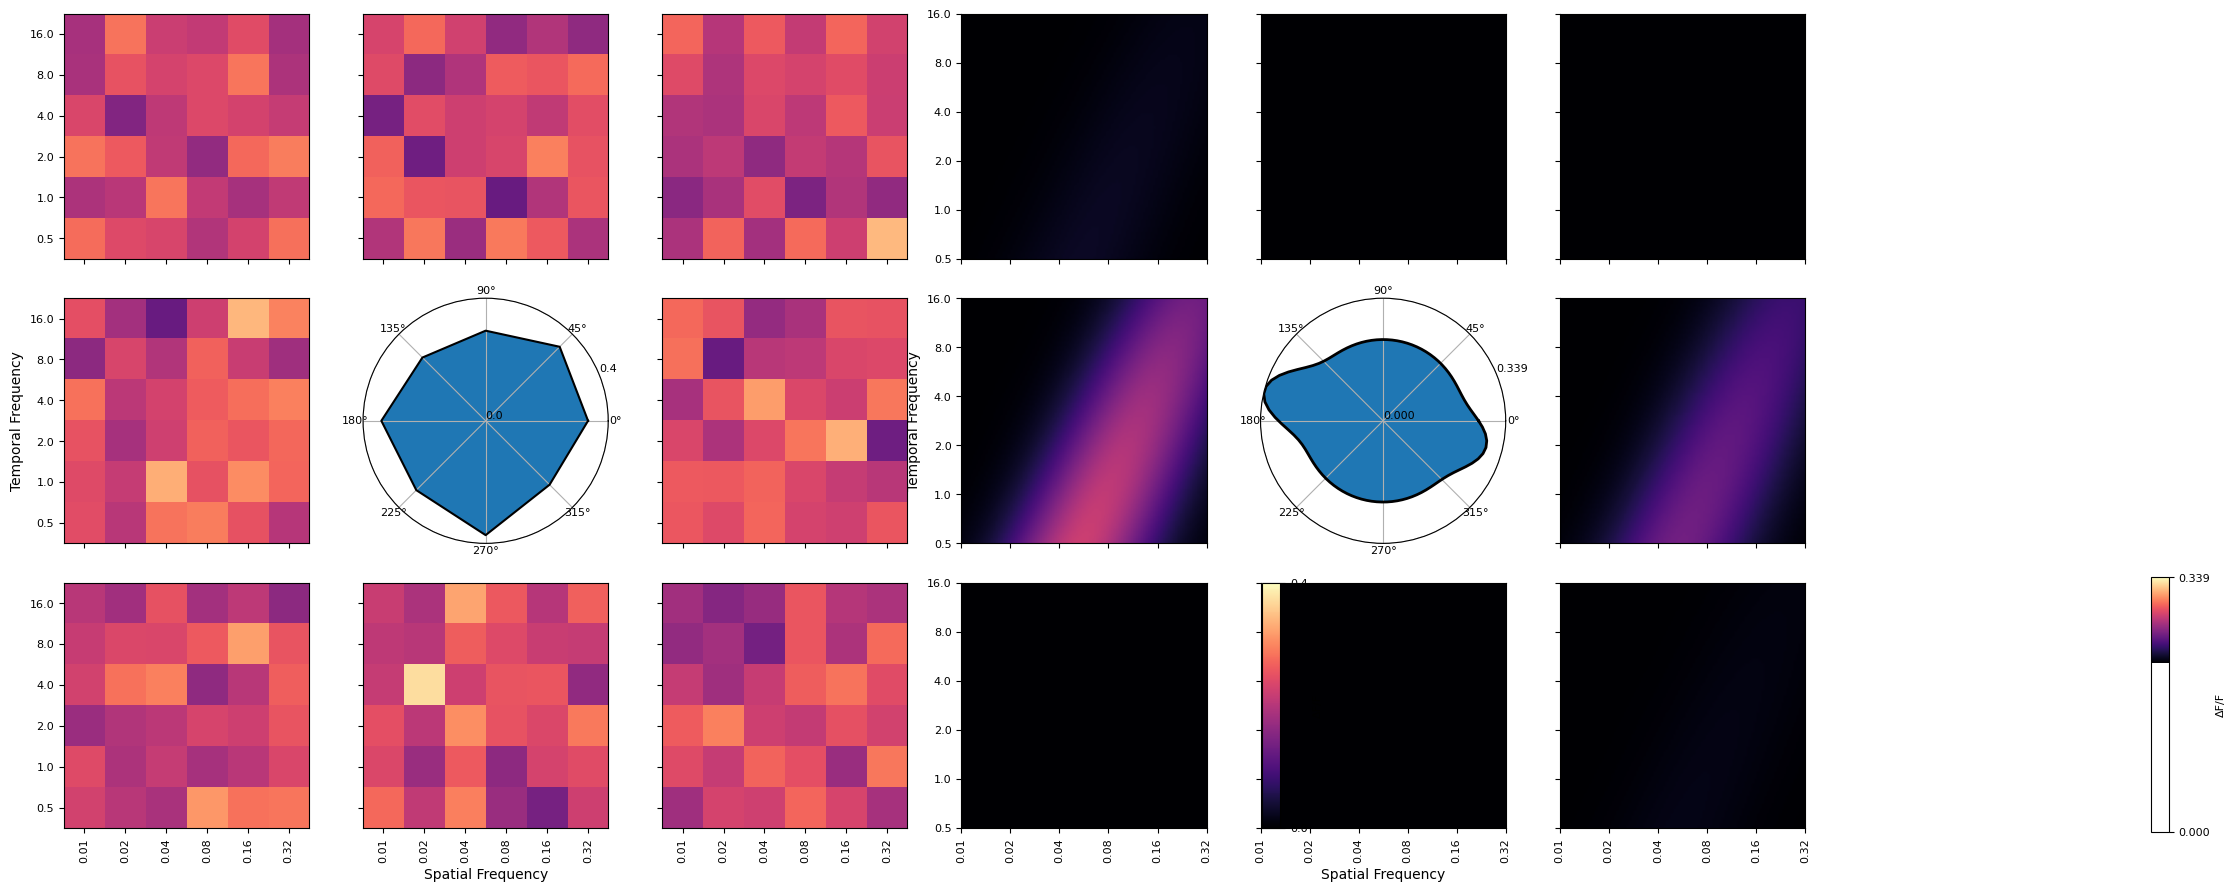

In [23]:
# Create a larger figure for the comparison
plt.figure(figsize=(15, 10))

print(f"Generating full report for ROI {found_rois}...")

grating_plots.basic_vis_SFTF_roi(
    neurons_df=neurons_df,
    trials_df_depth=None,          # No depth data
    trials_df_sftf=trials_df_formatted, # Use the formatted dataframe
    roi=found_rois,
    add_depth=False,
    fontsize_dict={'title': 12, 'label': 10, 'tick': 8}
)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from cottage_analysis.plotting import grating_plots

base_save_dir = Path("analysis_dataframes")
save_path = base_save_dir / mouse_name / session_name / protocol
trials_file = save_path / "trials_df.pkl"
neurons_file = save_path / "neurons_df.pkl"

if 'trials_df_formatted' not in locals() or 'neurons_df' not in locals():
    print("Data missing from memory. Loading from disk...")
    if not (trials_file.exists() and neurons_file.exists()):
        raise FileNotFoundError(f"Saved files not found at {save_path}.")

    neurons_df = pd.read_pickle(neurons_file)
    trials_df_raw = pd.read_pickle(trials_file)

    print("   Re-formatting trials dataframe...")
    response_matrix = np.stack(trials_df_raw['dff_stim'].apply(lambda x: np.mean(x, axis=0)).values)
    responses_df = pd.DataFrame(response_matrix, columns=np.arange(response_matrix.shape[1]), index=trials_df_raw.index)
    trials_df_formatted = pd.concat([trials_df_raw[['SpatialFrequency', 'TemporalFrequency', 'Angle']], responses_df], axis=1)
    print("Data ready.")


# --- CONFIGURATION ---
# We use a slightly higher R2 threshold (0.15) here. 
# Why? Very noisy neurons can sometimes generate artificial "single pixel" fits 
# that look infinitely sharp. We want to ensure the response is real first.
quality_threshold = 0.15
top_n_to_plot = 5 

# Filter for real, responsive neurons
good_neurons = neurons_df[neurons_df['rsq'] > quality_threshold].copy()
print(f"Filtering: Found {len(good_neurons)} selective neurons (R2 > {quality_threshold})")


# ==========================================
# 1. SHARPEST SPATIAL FREQUENCY TUNING
# ==========================================
print("\n" + "="*50)
print(f"🎯 SHARPEST SPATIAL FREQUENCY TUNING (Smallest Width)")
print("   (These neurons are very picky about bar thickness)")
print("="*50)

# Sort by Sigma (Width) -> Ascending (Smallest width first)
sf_selective = good_neurons.sort_values(by='log_sigma_x2', ascending=True)

for roi_id in sf_selective.index[:top_n_to_plot]:
    row = neurons_df.loc[roi_id]
    width_score = row['log_sigma_x2']
    print(f"ROI {roi_id}: SF Width={width_score:.2f} (Lower is sharper) | Pref={row['sf0']:.2f} cpd | R2={row['rsq']:.2f}")
    
    plt.figure(figsize=(5, 5))
    grating_plots.plot_sftf_tuning(trials_df=trials_df_formatted, roi=roi_id, plot_grid=True)
    plt.show()


# ==========================================
# 2. SHARPEST TEMPORAL FREQUENCY TUNING
# ==========================================
print("\n" + "="*50)
print(f"🎯 SHARPEST TEMPORAL FREQUENCY TUNING (Smallest Width)")
print("   (These neurons are very picky about speed)")
print("="*50)

# Sort by Sigma Y (TF Width) -> Ascending
tf_selective = good_neurons.sort_values(by='log_sigma_y2', ascending=True)

for roi_id in tf_selective.index[:top_n_to_plot]:
    row = neurons_df.loc[roi_id]
    width_score = row['log_sigma_y2']
    print(f"ROI {roi_id}: TF Width={width_score:.2f} (Lower is sharper) | Pref={row['tf0']:.2f} Hz | R2={row['rsq']:.2f}")
    
    plt.figure(figsize=(5, 5))
    grating_plots.plot_sftf_tuning(trials_df=trials_df_formatted, roi=roi_id, plot_grid=True)
    plt.show()


# ==========================================
# 3. SHARPEST DIRECTION TUNING
# ==========================================
print("\n" + "="*50)
print(f"🎯 SHARPEST DIRECTION TUNING (Highest Kappa)")
print("   (These neurons only look in one specific direction)")
print("="*50)

# Sort by Kappa (Concentration) -> Descending (Higher is sharper)
dir_selective = good_neurons.sort_values(by='log_kappa', ascending=False)

for roi_id in dir_selective.index[:top_n_to_plot]:
    row = neurons_df.loc[roi_id]
    kappa_score = row['log_kappa']
    deg = np.degrees(row['alpha0']) % 360
    print(f"ROI {roi_id}: Kappa={kappa_score:.2f} (Higher is sharper) | Pref={deg:.0f}° | R2={row['rsq']:.2f}")
    
    plt.figure(figsize=(5, 5))
    grating_plots.plot_sftf_tuning(trials_df=trials_df_formatted, roi=roi_id, plot_grid=True)
    plt.show()